In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Nov 23 11:39:44 2020

@author: berar
"""
import numpy as np
import time
import matplotlib.pyplot as plt


GRID_SIZE = 8
TERMINAL_STATES = [0, GRID_SIZE*GRID_SIZE-1]
states = np.arange(GRID_SIZE*GRID_SIZE)
actions = ['UP', 'RIGHT', 'DOWN', 'LEFT']
discount = 1.

def next_state(grid_size, state, action):
    i,j = np.unravel_index(state, (grid_size, grid_size))
    if action == 'UP':
        i = np.maximum(0,i-1)
    elif action == 'DOWN':
        i = np.minimum(i+1,grid_size-1)
    elif action == 'RIGHT':
        j = np.minimum(j+1,grid_size-1)
    elif action == 'LEFT':
        j = np.maximum(0,j-1)    
    new_state = np.ravel_multi_index((i,j), (grid_size, grid_size))
    return new_state
    
def is_done(state, terminal_states):
    return state in terminal_states


# The unifom policy            
uniform_policy = {s : { a : 1/len(actions) for a in actions } for s in states}

# Transition is coded as a dictionary of dictionary
P = {}
for s in range(len(states)):
    P[s] = {a : () for a in actions}
    if s in TERMINAL_STATES:
        # if terminal state, stay where you are
        # instead of next_state
        reward = 0.
        for action in actions:
            P[s][action] = (s, reward, True)
    else:
        # transition
        reward = -1.
        for action in actions:
            next_s = next_state(GRID_SIZE, s, action)
            P[s][action] = (next_s,reward,is_done(next_s, TERMINAL_STATES))
 

### Policy Evaluation

In [3]:
def Policy_Evaluation(policy, P, states, terminal_states, actions, discount=1.0, theta=1e-4):
    V = np.zeros(len(states))
    while True:
        delta = 0
        for s in states:
            if s in terminal_states:
                continue
            v = V[s]
            new_v = 0
            for a in actions:
                prob = policy[s][a]
                next_s, reward, done = P[s][a]
                new_v += prob * (reward + discount * V[next_s])
            V[s] = new_v
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    return V

In [4]:
V = Policy_Evaluation(uniform_policy, P, states, TERMINAL_STATES, actions)

print("Optimal Value Function:")
print(np.round(V.reshape(GRID_SIZE, GRID_SIZE), 2))

Optimal Value Function:
[[   0.    -62.    -96.79 -117.94 -131.12 -139.14 -143.64 -145.64]
 [ -62.    -85.21 -106.42 -121.93 -132.28 -138.65 -142.14 -143.64]
 [ -96.79 -106.42 -117.74 -127.07 -133.42 -137.04 -138.65 -139.14]
 [-117.94 -121.93 -127.07 -131.19 -133.3  -133.42 -132.28 -131.12]
 [-131.12 -132.28 -133.42 -133.3  -131.19 -127.07 -121.93 -117.94]
 [-139.14 -138.65 -137.04 -133.42 -127.07 -117.74 -106.42  -96.79]
 [-143.64 -142.14 -138.65 -132.28 -121.93 -106.42  -85.21  -62.  ]
 [-145.64 -143.64 -139.14 -131.12 -117.94  -96.79  -62.      0.  ]]


### Policy Iteration

In [5]:
def Policy_Iteration(policy, P, states, terminal_states, actions, discount=1.0, theta=1e-4):
    # Step 1: Initialize policy arbitrarily (uniform)
    policy = policy
    
    # Initial arbitrary deterministic policy for improvement step
    pi = {s: actions[0] for s in states if s not in terminal_states}
    
    while True:
        # Step 2: Policy Evaluation
        V = Policy_Evaluation(policy, P, states, terminal_states, actions, discount, theta)
        
        # Step 3: Policy Improvement
        policy_stable = True
        for s in states:
            if s in terminal_states:
                continue
            
            old_action = pi[s]
            
            # Evaluate all actions and pick the best one
            action_values = {}
            for a in actions:
                next_s, reward, done = P[s][a]
                action_values[a] = reward + discount * V[next_s]
            
            # Choose best action
            best_action = max(action_values, key=action_values.get)
            pi[s] = best_action
            
            # Update policy to deterministic (1.0 for best action)
            policy[s] = {a: 1.0 if a == best_action else 0.0 for a in actions}
            
            if best_action != old_action:
                policy_stable = False
        
        if policy_stable:
            break
    
    return V, pi


In [6]:
V_star, pi_star = Policy_Iteration(uniform_policy, P, states, TERMINAL_STATES, actions)

print("Optimal Value Function:")
print(np.round(V_star.reshape(GRID_SIZE, GRID_SIZE), 2))

# Format policy into grid arrows
policy_grid = np.full((GRID_SIZE, GRID_SIZE), '', dtype='<U5')
arrow_map = {'UP': '↑', 'DOWN': '↓', 'LEFT': '←', 'RIGHT': '→'}

for s in states:
    if s in TERMINAL_STATES:
        i, j = np.unravel_index(s, (GRID_SIZE, GRID_SIZE))
        policy_grid[i, j] = 'T'
    else:
        i, j = np.unravel_index(s, (GRID_SIZE, GRID_SIZE))
        policy_grid[i, j] = arrow_map[pi_star[s]]

print("\nOptimal Policy:")
for row in policy_grid:
    print(' '.join(row))


Optimal Value Function:
[[ 0. -1. -2. -3. -4. -5. -6. -7.]
 [-1. -2. -3. -4. -5. -6. -7. -6.]
 [-2. -3. -4. -5. -6. -7. -6. -5.]
 [-3. -4. -5. -6. -7. -6. -5. -4.]
 [-4. -5. -6. -7. -6. -5. -4. -3.]
 [-5. -6. -7. -6. -5. -4. -3. -2.]
 [-6. -7. -6. -5. -4. -3. -2. -1.]
 [-7. -6. -5. -4. -3. -2. -1.  0.]]

Optimal Policy:
T ← ← ← ← ← ← ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↓
↑ ↑ ↑ ↑ ↑ ↑ → ↓
↑ ↑ ↑ ↑ ↑ → → ↓
↑ ↑ ↑ ↑ → → → ↓
↑ ↑ ↑ → → → → ↓
↑ ↑ → → → → → ↓
↑ → → → → → → T


### Value Iteration

In [7]:
def Value_Iteration(P, states, terminal_states, actions, discount=1.0, theta=1e-4):
    V = np.zeros(len(states))

    while True:
        delta = 0
        for s in states:
            if s in terminal_states:
                continue

            v = V[s]

            # Compute Q(s, a) for all actions
            q_values = []
            for a in actions:
                next_s, reward, done = P[s][a]
                q = reward + discount * V[next_s]
                q_values.append(q)

            V[s] = max(q_values)
            delta = max(delta, abs(v - V[s]))

        if delta < theta:
            break

    # Derive policy from final value function
    pi = {}
    for s in states:
        if s in terminal_states:
            continue

        action_values = {}
        for a in actions:
            next_s, reward, done = P[s][a]
            action_values[a] = reward + discount * V[next_s]

        # Best action for this state
        best_action = max(action_values, key=action_values.get)
        pi[s] = best_action

    return V, pi


In [8]:
V_star, pi_star = Value_Iteration(P, states, TERMINAL_STATES, actions)

# Format value function
print("Optimal Value Function (Value Iteration):")
print(np.round(V_star.reshape(GRID_SIZE, GRID_SIZE), 2))

# Visualize policy
policy_grid = np.full((GRID_SIZE, GRID_SIZE), '', dtype='<U5')
arrow_map = {'UP': '↑', 'DOWN': '↓', 'LEFT': '←', 'RIGHT': '→'}

for s in states:
    i, j = np.unravel_index(s, (GRID_SIZE, GRID_SIZE))
    if s in TERMINAL_STATES:
        policy_grid[i, j] = 'T'
    else:
        policy_grid[i, j] = arrow_map[pi_star[s]]

print("\nOptimal Policy (Value Iteration):")
for row in policy_grid:
    print(' '.join(row))


Optimal Value Function (Value Iteration):
[[ 0. -1. -2. -3. -4. -5. -6. -7.]
 [-1. -2. -3. -4. -5. -6. -7. -6.]
 [-2. -3. -4. -5. -6. -7. -6. -5.]
 [-3. -4. -5. -6. -7. -6. -5. -4.]
 [-4. -5. -6. -7. -6. -5. -4. -3.]
 [-5. -6. -7. -6. -5. -4. -3. -2.]
 [-6. -7. -6. -5. -4. -3. -2. -1.]
 [-7. -6. -5. -4. -3. -2. -1.  0.]]

Optimal Policy (Value Iteration):
T ← ← ← ← ← ← ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↓
↑ ↑ ↑ ↑ ↑ ↑ → ↓
↑ ↑ ↑ ↑ ↑ → → ↓
↑ ↑ ↑ ↑ → → → ↓
↑ ↑ ↑ → → → → ↓
↑ ↑ → → → → → ↓
↑ → → → → → → T


### Analysis

In [9]:
def init_problem(n):
    
    GRID_SIZE = n
    TERMINAL_STATES = [0, GRID_SIZE*GRID_SIZE-1]
    states = np.arange(GRID_SIZE*GRID_SIZE)
    uniform_policy = {s : { a : 1/len(actions) for a in actions } for s in states}
    
    P = {}
    for s in range(len(states)):
        P[s] = {a : () for a in actions}
        if s in TERMINAL_STATES:
            # if terminal state, stay where you are
            # instead of next_state
            reward = 0.
            for action in actions:
                P[s][action] = (s, reward, True)
        else:
            # transition
            reward = -1.
            for action in actions:
                next_s = next_state(GRID_SIZE, s, action)
                P[s][action] = (next_s,reward,is_done(next_s, TERMINAL_STATES))
                
    return uniform_policy, P, states, TERMINAL_STATES

In [11]:
values_n = [5, 10, 15, 20, 25, 30]
t_pol = []
t_val = []

for n in values_n:

    uniform_policy, P, states, TERMINAL_STATES = init_problem(n)

    print("----- n = ",n," -----")  
    tic = time.time()
    %time _, _ = Policy_Iteration(uniform_policy, P, states, TERMINAL_STATES, actions)
    toc = time.time()
    elapsed_time = toc - tic
    t_pol.append(elapsed_time)
    
    tic = time.time()
    %time _, _ = Value_Iteration(P, states, TERMINAL_STATES, actions)
    toc = time.time()
    elapsed_time = toc - tic
    t_val.append(elapsed_time)

----- n =  5  -----
CPU times: total: 15.6 ms
Wall time: 34.7 ms
CPU times: total: 0 ns
Wall time: 0 ns
----- n =  10  -----
CPU times: total: 312 ms
Wall time: 738 ms
CPU times: total: 0 ns
Wall time: 15.9 ms
----- n =  15  -----
CPU times: total: 2.67 s
Wall time: 4.76 s
CPU times: total: 0 ns
Wall time: 18 ms
----- n =  20  -----
CPU times: total: 5.56 s
Wall time: 13.2 s
CPU times: total: 15.6 ms
Wall time: 31.3 ms
----- n =  25  -----
CPU times: total: 14.8 s
Wall time: 33.2 s
CPU times: total: 15.6 ms
Wall time: 70 ms
----- n =  30  -----
CPU times: total: 37.6 s
Wall time: 1min 16s
CPU times: total: 78.1 ms
Wall time: 121 ms


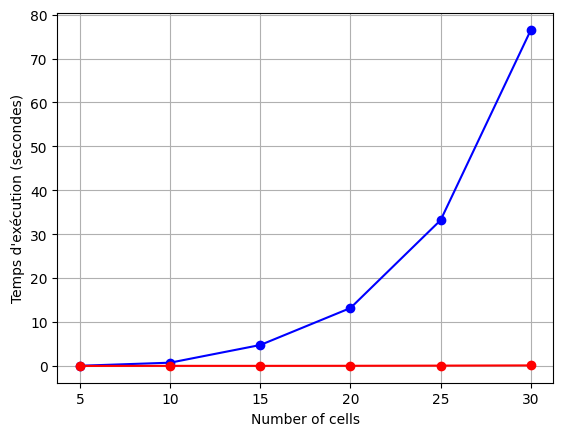

In [15]:
plt.plot(values_n, t_pol, marker='o', color='blue')
plt.plot(values_n, t_val, marker='o', color='red')
plt.xlabel('Number of cells')
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.show()